<div style="text-align: center;">
    <h1 style="font-size: 64px; 
               font-weight: 800;
               color: #1f0d4f;
               letter-spacing: 2px;
               margin: 40px 0;">
        LISTA 6
    </h1>
</div>

# Zad 1. Stwórz własną klasę implementującą binarne drzewa przeszukiwań. Zadbaj o poprawne przetwarzanie powtarzających się kluczy

In [7]:
from __future__ import annotations
from typing import TypeVar, Generic, Optional, Callable

T = TypeVar("T")

class _BSTNode(Generic[T]):
    __slots__ = ("key", "count", "left", "right")

    key: T
    count: int
    left: Optional[_BSTNode[T]]
    right: Optional[_BSTNode[T]] 

    def __init__(self, key: T) -> None:
        self.key = key
        self.count = 1
        self.left = None
        self.right = None


class BinarySearchTree(Generic[T]):
    """Drzewo BST z obsługą duplikatów przez zliczanie."""

    __slots__ = ("_root", "_size", "_cmp")

    _root: Optional[_BSTNode[T]]
    _size: int
    _cmp: Callable[[T, T], int]

    def __init__(self, cmp: Optional[Callable[[T, T], int]] = None) -> None:
        self._root = None
        self._size = 0
        self._cmp = cmp if cmp is not None else self._default_cmp

    @staticmethod
    def _default_cmp(a: T, b: T) -> int:
        if a < b:  # type: ignore[operator]
            return -1
        if a == b:
            return 0
        return 1

    def __len__(self) -> int:
        return self._size

    def __bool__(self) -> bool:
        return self._size > 0

    def __contains__(self, key: T) -> bool:
        return self.search(key)

    def insert(self, key: T) -> None:
        """Wstawia klucz. Duplikaty zwiększają licznik."""
        if self._root is None:
            self._root = _BSTNode(key)
            self._size += 1
        else:
            self._insert(self._root, key)

    def _insert(self, node: _BSTNode[T], key: T) -> None:
        cmp_result: int = self._cmp(key, node.key)

        if cmp_result == 0:
            node.count += 1
            self._size += 1
        elif cmp_result < 0:
            if node.left is None:
                node.left = _BSTNode(key)
                self._size += 1
            else:
                self._insert(node.left, key)
        else:
            if node.right is None:
                node.right = _BSTNode(key)
                self._size += 1
            else:
                self._insert(node.right, key)

    def search(self, key: T) -> bool:
        """Zwraca True jeśli klucz istnieje."""
        return self._search(self._root, key)

    def _search(self, node: Optional[_BSTNode[T]], key: T) -> bool:
        if node is None:
            return False

        cmp_result: int = self._cmp(key, node.key)

        if cmp_result == 0:
            return True
        if cmp_result < 0:
            return self._search(node.left, key)
        return self._search(node.right, key)

    def delete(self, key: T) -> bool:
        """Usuwa jedno wystąpienie klucza. Zwraca True jeśli usunięto."""
        found: list[bool] = [False]
        self._root = self._delete(self._root, key, found)
        if found[0]:
            self._size -= 1
        return found[0]

    def _delete(
        self, node: Optional[_BSTNode[T]], key: T, found: list[bool]
    ) -> Optional[_BSTNode[T]]:
        if node is None:
            return None

        cmp_result: int = self._cmp(key, node.key)

        if cmp_result < 0:
            node.left = self._delete(node.left, key, found)
        elif cmp_result > 0:
            node.right = self._delete(node.right, key, found)
        else:
            found[0] = True
            if node.count > 1:
                node.count -= 1
                return node

            # Usuwanie węzła
            if node.left is None:
                return node.right
            if node.right is None:
                return node.left

            # Dwa dzieci - następnik in-order
            successor: _BSTNode[T] = self._find_min(node.right)
            node.key = successor.key
            node.count = successor.count
            successor.count = 1
            node.right = self._delete(node.right, successor.key, [False])

        return node

    @staticmethod
    def _find_min(node: _BSTNode[T]) -> _BSTNode[T]:
        while node.left is not None:
            node = node.left
        return node

    def min(self) -> Optional[T]:
        """Zwraca minimalny klucz lub None."""
        if self._root is None:
            return None
        return self._find_min(self._root).key

    def max(self) -> Optional[T]:
        """Zwraca maksymalny klucz lub None."""
        if self._root is None:
            return None
        node: _BSTNode[T] = self._root
        while node.right is not None:
            node = node.right
        return node.key

    def clear(self) -> None:
        """Usuwa wszystkie elementy."""
        self._root = None
        self._size = 0

    def inorder(self) -> list[T]:
        """Zwraca elementy in-order (posortowane, z powtórzeniami)."""
        result: list[T] = []
        self._inorder(self._root, result)
        return result

    def _inorder(self, node: Optional[_BSTNode[T]], result: list[T]) -> None:
        if node is not None:
            self._inorder(node.left, result)
            result.extend([node.key] * node.count)
            self._inorder(node.right, result)

    def preorder(self) -> list[T]:
        """Zwraca elementy pre-order."""
        result: list[T] = []
        self._preorder(self._root, result)
        return result

    def _preorder(self, node: Optional[_BSTNode[T]], result: list[T]) -> None:
        if node is not None:
            result.extend([node.key] * node.count)
            self._preorder(node.left, result)
            self._preorder(node.right, result)


    def display(self) -> None:
        """Wyświetla drzewo in-order."""
        print("BST (in-order):", self.inorder())

    def __str__(self) -> str:
        lines: list[str] = []
        self._build_str(self._root, "", True, lines, is_root=True)
        return "\n".join(lines) if lines else "(empty tree)"

    def _build_str(
        self,
        node: Optional[_BSTNode[T]],
        prefix: str,
        is_last: bool,
        lines: list[str],
        is_root: bool = False,
    ) -> None:
        if node is None:
            return

        label: str = f"{node.key}" if node.count == 1 else f"{node.key}(×{node.count})"

        if is_root:
            lines.append(label)
            new_prefix = ""
        else:
            connector: str = "└── " if is_last else "├── "
            lines.append(prefix + connector + label)
            new_prefix = prefix + ("    " if is_last else "│   ")

        has_left: bool = node.left is not None
        has_right: bool = node.right is not None

        if has_left:
            self._build_str(node.left, new_prefix, not has_right, lines)
        if has_right:
            self._build_str(node.right, new_prefix, True, lines)

    def __repr__(self) -> str:
        return f"BinarySearchTree({self.inorder()})"



bst: BinarySearchTree[int] = BinarySearchTree()

for x in [5, 3, 7, 2, 4, 6, 8, 3]:
    bst.insert(x)

bst.display()
print(f"{bst}")


print(f"Czy 5 jest w drzewie? {bst.search(5)}")
print(f"Czy 10 jest w drzewie? {bst.search(10)}")

print("Usunięcie 5 z korzenia:")
bst.delete(5)
print(f"{bst}")

print("Usunięcie 3 (duplikat):")
bst.delete(3)
print(f"{bst}")

print("Wartość minimalna:", bst.min())
print("Wartość maksymalna:", bst.max())

print("Elementy pre-order:", f"{bst.preorder()}")

BST (in-order): [2, 3, 3, 4, 5, 6, 7, 8]
5
├── 3(×2)
│   ├── 2
│   └── 4
└── 7
    ├── 6
    └── 8
Czy 5 jest w drzewie? True
Czy 10 jest w drzewie? False
Usunięcie 5 z korzenia:
6
├── 3(×2)
│   ├── 2
│   └── 4
└── 7
    └── 8
Usunięcie 3 (duplikat):
6
├── 3
│   ├── 2
│   └── 4
└── 7
    └── 8
Wartość minimalna: 2
Wartość maksymalna: 8
Elementy pre-order: [6, 3, 2, 4, 7, 8]


# Zad 2.
**Zaimplementuj kopiec binarny. Korzystając z tego kopca napisz funkcję
sortującą listę elementów w czasie $\mathcal{O}(n log n)$. Przeprowadź analizę eksperymentalną czasu wykonania algorytmu.**

In [2]:
from __future__ import annotations
from typing import TypeVar, Generic, Optional, Callable

T = TypeVar("T")


class BinaryHeap(Generic[T]):
    __slots__ = ("_data", "_cmp")

    _data: list[T]
    _cmp: Callable[[T, T], int]

    def __init__(self, cmp: Optional[Callable[[T, T], int]] = None) -> None:
        self._data = []
        self._cmp = cmp if cmp is not None else self._default_cmp

    @staticmethod
    def _default_cmp(a: T, b: T) -> int:
        if a < b:  # type: ignore[operator]
            return -1
        if a == b:
            return 0
        return 1

    # Indeksy

    @staticmethod
    def _parent(i: int) -> int:
        return (i - 1) >> 1

    @staticmethod
    def _left(i: int) -> int:
        return (i << 1) | 1

    @staticmethod
    def _right(i: int) -> int:
        return (i << 1) + 2

    def __len__(self) -> int:
        return len(self._data)

    def __bool__(self) -> bool:
        return len(self._data) > 0

    def peek(self) -> Optional[T]:
        """Zwraca minimum bez usuwania."""
        return self._data[0] if self._data else None


    def insert(self, value: T) -> None:
        """Wstawia element do kopca."""
        self._data.append(value)
        self._sift_up(len(self._data) - 1)

    def _sift_up(self, i: int) -> None:
        """Przywraca własność kopca w górę."""
        data = self._data
        cmp = self._cmp
        while i > 0:
            parent: int = (i - 1) >> 1
            if cmp(data[i], data[parent]) >= 0:
                break
            data[i], data[parent] = data[parent], data[i]
            i = parent

    def remove(self) -> Optional[T]:
        """Usuwa i zwraca minimum."""
        if not self._data:
            return None

        data = self._data
        result: T = data[0]

        if len(data) == 1:
            data.pop()
        else:
            data[0] = data.pop()
            self._sift_down(0)

        return result

    def _sift_down(self, i: int) -> None:
        """Przywraca własność kopca w dół."""
        data = self._data
        cmp = self._cmp
        n: int = len(data)

        while True:
            smallest: int = i
            left: int = (i << 1) | 1
            right: int = (i << 1) + 2

            if left < n and cmp(data[left], data[smallest]) < 0:
                smallest = left
            if right < n and cmp(data[right], data[smallest]) < 0:
                smallest = right

            if smallest == i:
                break

            data[i], data[smallest] = data[smallest], data[i]
            i = smallest

    def heapify(self, items: list[T]) -> None:
        """Buduje kopiec z listy."""
        self._data = items.copy()
        n: int = len(self._data)
        # Zaczynamy od ostatniego rodzica
        for i in range((n >> 1) - 1, -1, -1):
            self._sift_down(i)

    def clear(self) -> None:
        """Czyści kopiec."""
        self._data.clear()


    def display(self) -> None:
        """Wyświetla zawartość kopca."""
        print(f"Heap (size={len(self._data)}): {self._data}")

    def __str__(self) -> str:
        if not self._data:
            return "Pusty kopiec :()"

        lines: list[str] = []
        self._build_str(0, "", True, lines, is_root=True)
        return "\n".join(lines)

    def _build_str(
        self,
        i: int,
        prefix: str,
        is_last: bool,
        lines: list[str],
        is_root: bool = False,
    ) -> None:
        if i >= len(self._data):
            return

        if is_root:
            lines.append(str(self._data[i]))
            new_prefix = ""
        else:
            connector: str = "└── " if is_last else "├── "
            lines.append(prefix + connector + str(self._data[i]))
            new_prefix = prefix + ("    " if is_last else "│   ")

        left: int = (i << 1) | 1
        right: int = (i << 1) + 2
        has_left: bool = left < len(self._data)
        has_right: bool = right < len(self._data)

        if has_left:
            self._build_str(left, new_prefix, not has_right, lines)
        if has_right:
            self._build_str(right, new_prefix, True, lines)

    def __repr__(self) -> str:
        return f"BinaryHeap({self._data})"



heap: BinaryHeap[int] = BinaryHeap()


for x in [5, 3, 8, 1, 7, 2, 9]:
    heap.insert(x)

print(f"{heap}")

1
├── 3
│   ├── 5
│   └── 7
└── 2
    ├── 8
    └── 9


## Analiza eksperymentlana:

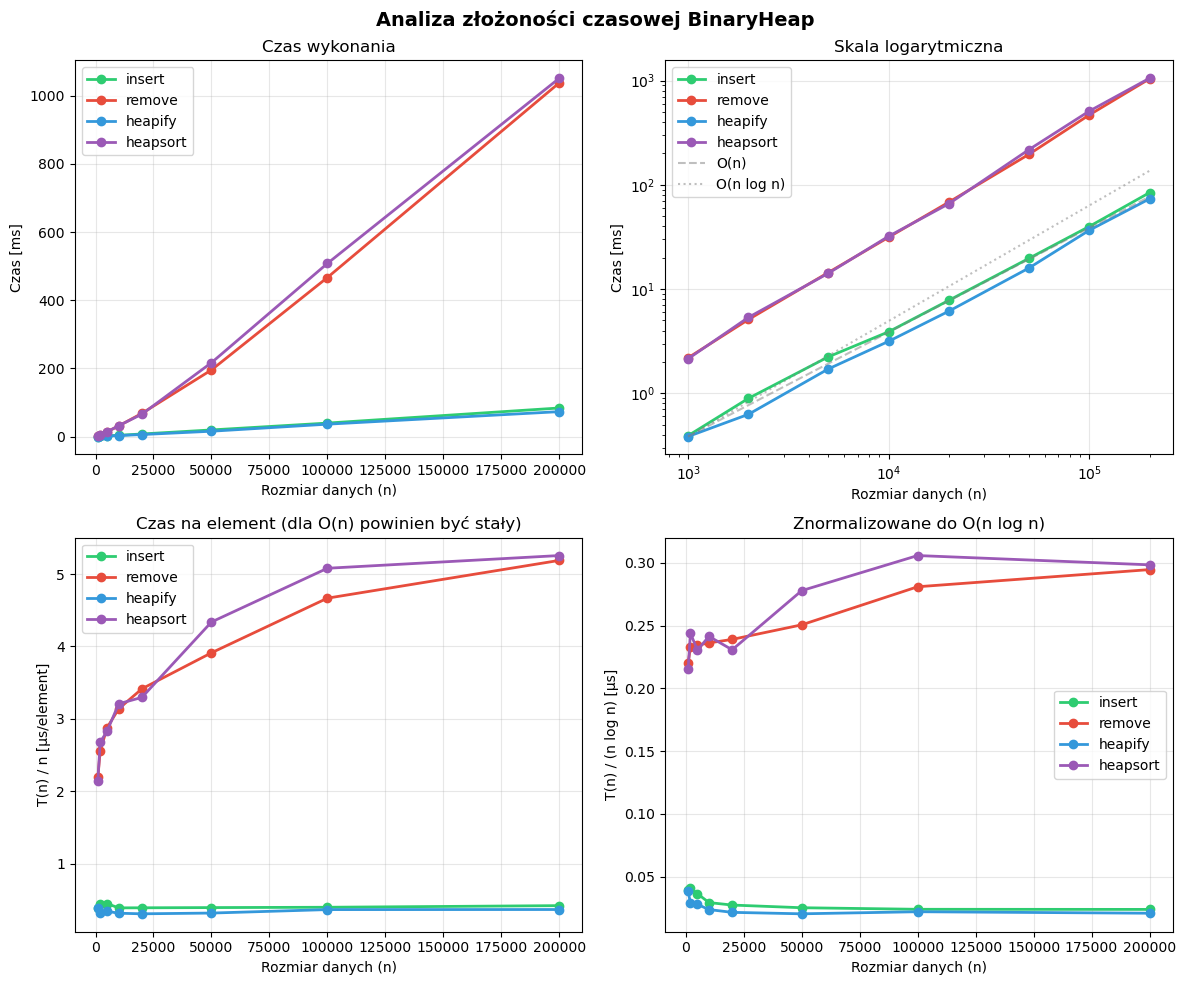

In [3]:
import time
import random
import math
import matplotlib.pyplot as plt
import matplotlib

def measure_time(func: Callable[[], None], repeats: int = 5) -> float:
    times: list[float] = []
    for _ in range(repeats):
        start = time.perf_counter()
        func()
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)


def benchmark_insert(n: int) -> float:
    data = [random.randint(0, 10 * n) for _ in range(n)]
    
    def run() -> None:
        heap: BinaryHeap[int] = BinaryHeap()
        for x in data:
            heap.insert(x)
    
    return measure_time(run)


def benchmark_remove(n: int) -> float:
    data = [random.randint(0, 10 * n) for _ in range(n)]
    
    def run() -> None:
        heap: BinaryHeap[int] = BinaryHeap()
        heap.heapify(data.copy())
        while heap:
            heap.remove()
    
    return measure_time(run)


def benchmark_heapify(n: int) -> float:
    data = [random.randint(0, 10 * n) for _ in range(n)]
    
    def run() -> None:
        heap: BinaryHeap[int] = BinaryHeap()
        heap.heapify(data.copy())
    
    return measure_time(run)


def benchmark_heapsort(n: int) -> float:
    data = [random.randint(0, 10 * n) for _ in range(n)]
    
    def run() -> None:
        heap: BinaryHeap[int] = BinaryHeap()
        heap.heapify(data.copy())
        while heap:
            heap.remove()
    
    return measure_time(run)


def run_benchmarks() -> dict[str, list[tuple[int, float]]]:
    sizes = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000]
    
    results: dict[str, list[tuple[int, float]]] = {
        "insert": [],
        "remove": [],
        "heapify": [],
        "heapsort": [],
    }
    
    for n in sizes:
        t_insert = benchmark_insert(n)
        t_remove = benchmark_remove(n)
        t_heapify = benchmark_heapify(n)
        t_heapsort = benchmark_heapsort(n)
        
        results["insert"].append((n, t_insert))
        results["remove"].append((n, t_remove))
        results["heapify"].append((n, t_heapify))
        results["heapsort"].append((n, t_heapsort))

    
    return results

def plot_results(results: dict[str, list[tuple[int, float]]]) -> None:
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("Analiza złożoności czasowej BinaryHeap", fontsize=14, fontweight='bold')
    
    colors = {'insert': '#2ecc71', 'remove': '#e74c3c', 'heapify': '#3498db', 'heapsort': '#9b59b6'}
    
    # Wykres 1: Czasy bezwzględne
    ax1 = axes[0, 0]
    for name, data in results.items():
        sizes = [n for n, _ in data]
        times = [t * 1000 for _, t in data]  # ms
        ax1.plot(sizes, times, 'o-', label=name, color=colors[name], linewidth=2, markersize=6)
    
    ax1.set_xlabel("Rozmiar danych (n)")
    ax1.set_ylabel("Czas [ms]")
    ax1.set_title("Czas wykonania")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    for name, data in results.items():
        sizes = [n for n, _ in data]
        times = [t * 1000 for _, t in data]
        ax2.loglog(sizes, times, 'o-', label=name, color=colors[name], linewidth=2, markersize=6)
    
    n_ref = [sizes[0], sizes[-1]]
    t_base = results['heapify'][0][1] * 1000
    n_base = results['heapify'][0][0]
    
    # O(n)
    ax2.loglog(n_ref, [t_base * n / n_base for n in n_ref], '--', color='gray', alpha=0.5, label='O(n)')
    # O(n log n)
    ax2.loglog(n_ref, [t_base * n * math.log2(n) / (n_base * math.log2(n_base)) for n in n_ref], 
               ':', color='gray', alpha=0.5, label='O(n log n)')
    
    ax2.set_xlabel("Rozmiar danych (n)")
    ax2.set_ylabel("Czas [ms]")
    ax2.set_title("Skala logarytmiczna")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[1, 0]
    for name, data in results.items():
        sizes = [n for n, _ in data]
        normalized = [t / n * 1e6 for n, t in data]  # μs per element
        ax3.plot(sizes, normalized, 'o-', label=name, color=colors[name], linewidth=2, markersize=6)
    
    ax3.set_xlabel("Rozmiar danych (n)")
    ax3.set_ylabel("T(n) / n [μs/element]")
    ax3.set_title("Czas na element (dla O(n) powinien być stały)")
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    for name, data in results.items():
        sizes = [n for n, _ in data]
        normalized = [t / (n * math.log2(n)) * 1e6 for n, t in data]
        ax4.plot(sizes, normalized, 'o-', label=name, color=colors[name], linewidth=2, markersize=6)
    
    ax4.set_xlabel("Rozmiar danych (n)")
    ax4.set_ylabel("T(n) / (n log n) [μs]")
    ax4.set_title("Znormalizowane do O(n log n)")
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



def main() -> None:
    results = run_benchmarks()
    plot_results(results)

main()

## Zad 3.
Zaimplementuj kopiec binarny o ograniczonej wielkości $n$. Innymi słowy, stwórz strukturę przechowującą $n$ najważniejszych wartości.

In [5]:
from __future__ import annotations
from typing import TypeVar, Generic, Optional, Callable

T = TypeVar("T")


class BoundedMaxHeap(Generic[T]):
    __slots__ = ("_heap", "_capacity", "_cmp")

    _heap: BinaryHeap[T]
    _capacity: int
    _cmp: Callable[[T, T], int]

    def __init__(
        self,
        capacity: int,
        cmp: Optional[Callable[[T, T], int]] = None,
    ) -> None:
        if capacity < 1:
            raise ValueError("Pojemność musi być >= 1")
        
        self._capacity = capacity
        self._cmp = cmp if cmp is not None else self._default_cmp
        # Min-heap wewnętrznie
        self._heap = BinaryHeap(cmp=self._cmp)

    @staticmethod
    def _default_cmp(a: T, b: T) -> int:
        if a < b:  # type: ignore[operator]
            return -1
        if a == b:
            return 0
        return 1

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

    @property
    def capacity(self) -> int:
        return self._capacity

    def is_full(self) -> bool:
        return len(self._heap) >= self._capacity

    def threshold(self) -> Optional[T]:
        return self._heap.peek()

    # Operacje

    def insert(self, value: T) -> bool:
        """
        Próbuje wstawić element.
        """
        if len(self._heap) < self._capacity:
            self._heap.insert(value)
            return True
        
        current_min: Optional[T] = self._heap.peek()
        if current_min is not None and self._cmp(value, current_min) > 0:
            self._heap.remove()  # Usuń najmniejszy
            self._heap.insert(value)
            return True
        
        return False  # Element za mały

    def remove(self) -> Optional[T]:
        return self._heap.remove()

    def get_top_n(self) -> list[T]:
        temp: BinaryHeap[T] = BinaryHeap(cmp=self._cmp)
        temp._data = self._heap._data.copy()
        
        result: list[T] = []
        while temp:
            val = temp.remove()
            if val is not None:
                result.append(val)
        
        return result[::-1]  # Odwracamy: od największego

    def clear(self) -> None:
        self._heap.clear()

    def display(self) -> None:
        print(f"BoundedMaxHeap (size={len(self)}/{self._capacity}): {self.get_top_n()}")

    def __str__(self) -> str:
        return f"Top-{self._capacity}: {self.get_top_n()}"

    def __repr__(self) -> str:
        return f"BoundedMaxHeap(capacity={self._capacity}, elements={self.get_top_n()})"

## Zad. 4 lista 5
Jeżeli wstawimy elementy ($1, A$), ($2, B$), ($3, C$), ($4, D$) i ($5, E$) do początkowo pustego drzewa binarnego, to jak będzie ono. wyglądać?

In [11]:
bst = BinarySearchTree()
data = [(1, 'A'), (2, 'B'), (3, 'C'), (4, 'D'), (5, 'E')]

for key, val in data:
    bst.insert([key,val])

print(f"{bst}")

[1, 'A']
└── [2, 'B']
    └── [3, 'C']
        └── [4, 'D']
            └── [5, 'E']


# Zad 5 lista 5
Do pustego drzewa binarnego wstawiamy kolejno klucze $30, 40, 24, 58,
48, 26, 11 \ \text{i} \ 13$. Narysuj drzewo po każdym wstawieniu

In [16]:
bst = BinarySearchTree()
data = [30, 40, 24, 58, 48, 26, 11 , 13]

for key in data:
    bst.insert(key)
    print(f"{bst}\n")

print(f"{bst}")

30

30
└── 40

30
├── 24
└── 40

30
├── 24
└── 40
    └── 58

30
├── 24
└── 40
    └── 58
        └── 48

30
├── 24
│   └── 26
└── 40
    └── 58
        └── 48

30
├── 24
│   ├── 11
│   └── 26
└── 40
    └── 58
        └── 48

30
├── 24
│   ├── 11
│   │   └── 13
│   └── 26
└── 40
    └── 58
        └── 48

30
├── 24
│   ├── 11
│   │   └── 13
│   └── 26
└── 40
    └── 58
        └── 48
